You are given an integer side, representing the edge length of a square with corners at (0, 0), (0, side), (side, 0), and (side, side) on a Cartesian plane.

You are also given a positive integer k and a 2D integer array points, where points[i] = [xi, yi] represents the coordinate of a point lying on the boundary of the square.

You need to select k elements among points such that the minimum Manhattan distance between any two points is maximized.

Return the maximum possible minimum Manhattan distance between the selected k points.

The Manhattan Distance between two cells (xi, yi) and (xj, yj) is |xi - xj| + |yi - yj|.

 

Example 1:

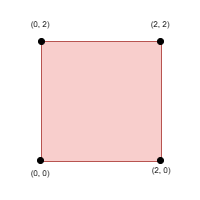

Input: side = 2, points = [[0,2],[2,0],[2,2],[0,0]], k = 4

Output: 2

Explanation:

Select all four points.

Example 2:

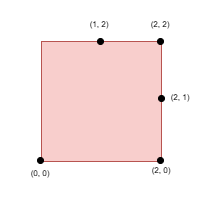

Input: side = 2, points = [[0,0],[1,2],[2,0],[2,2],[2,1]], k = 4

Output: 1

Explanation:

Select the points (0, 0), (2, 0), (2, 2), and (2, 1).

Example 3:

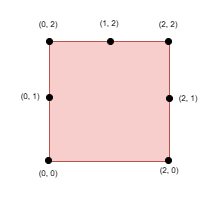

Input: side = 2, points = [[0,0],[0,1],[0,2],[1,2],[2,0],[2,2],[2,1]], k = 5

Output: 1

Explanation:

Select the points (0, 0), (0, 1), (0, 2), (1, 2), and (2, 2).

 

Constraints:

    1 <= side <= 109
    4 <= points.length <= min(4 * side, 15 * 103)
    points[i] == [xi, yi]
    The input is generated such that:
        points[i] lies on the boundary of the square.
        All points[i] are unique.
    4 <= k <= min(25, points.length)

 

In [ ]:
class Solution:
    def maxDistance(self, side: int, points: List[List[int]], k: int) -> int:
        arr = []
        
        for x, y in points:
            if x == 0:
                arr.append(y)
            elif y == side:
                arr.append(side + x)
            elif x == side:
                arr.append(side * 3 - y)
            else:
                arr.append(side * 4 - x)
        
        arr.sort()
        
        def check(limit: int) -> bool:
            perimeter = side * 4
            for start in arr:
                end = start + perimeter - limit
                cur = start
                for _ in range(k - 1):
                    idx = bisect_left(arr, cur + limit)
                    if idx == len(arr) or arr[idx] > end:
                        cur = -1
                        break
                    cur = arr[idx]
                if cur >= 0:
                    return True
            return False
        
        lo, hi = 1, side
        ans = 0
        
        while lo <= hi:
            mid = (lo + hi) // 2
            if check(mid):
                lo = mid + 1
                ans = mid
            else:
                hi = mid - 1
                
        return ans